<a href="https://colab.research.google.com/github/asdiFlv3/PHAS0056_assignments/blob/main/continuous_assessments/CW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


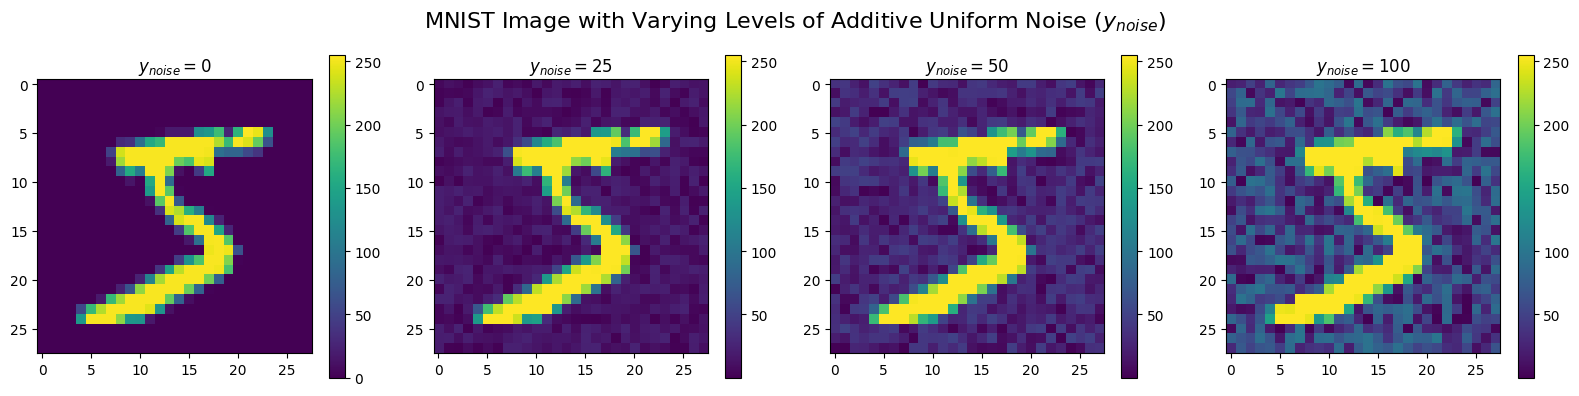

In [2]:
def addNoiseToMNIST(yNoise, data):
  data = np.array(data, dtype=np.float32)
  noise = np.random.uniform(low=0.0, high=yNoise, size=data.shape) # random noise
  noisy_data = data + noise
  # ensure no pixel > 255 and no pixel < 0
  noisy_data = np.clip(noisy_data, 0.0, 255.0)
  return noisy_data

mnist = keras.datasets.mnist   #The original handwritten digit MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data() # load MNIST
original_image = train_images[0]

noise_levels = [0, 25, 50, 100] # y_noises

# plot image from the MNIST data set with the noise values
plt.figure(figsize=(16, 4))
plt.suptitle(f'MNIST Image with Varying Levels of Additive Uniform Noise ($y_{{noise}}$)', fontsize=16)
# loop through the noise levels
n_cols = len(noise_levels)

for i, y_noise in enumerate(noise_levels):
    # apply noise
    noisy_img = addNoiseToMNIST(y_noise, original_image.copy())
    # index' is 1-based so i + 1
    plt.subplot(1, n_cols, i + 1)
    plt.imshow(noisy_img)
    plt.title(f'$y_{{noise}} = {y_noise}$')
    plt.colorbar()

plt.tight_layout()
plt.show()


In [4]:
# scale pixel values to the [0, 1] range
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
train_images_norm = train_images / 255.0
test_images_norm = test_images / 255.0

def build_and_train_model(x_train, y_train, epochs=10):
  # define the layers of model
  model = keras.Sequential([
      keras.layers.Flatten(input_shape=(28, 28)),
      keras.layers.Dense(32, activation='relu'),
      keras.layers.Dense(10) # output layer (logits)
  ])

  # fit the model to data
  model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              metrics=['accuracy'])
  # add validation_data so you can see the test accuracy *during* trainin
  history = model.fit(x_train, y_train, epochs=epochs, batch_size=64, validation_split=0.1, verbose=1)
  return model

# train on clean, normalized data
clean_model = build_and_train_model(train_images_norm, train_labels, epochs=10)

# verify performance
loss, acc = clean_model.evaluate(test_images_norm, test_labels, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5238 - loss: 1.6242 - val_accuracy: 0.8892 - val_loss: 0.4975
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8675 - loss: 0.5180 - val_accuracy: 0.9138 - val_loss: 0.3458
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8910 - loss: 0.4003 - val_accuracy: 0.9212 - val_loss: 0.2985
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9027 - loss: 0.3503 - val_accuracy: 0.9262 - val_loss: 0.2734
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9062 - loss: 0.3315 - val_accuracy: 0.9303 - val_loss: 0.2567
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9112 - loss: 0.3171 - val_accuracy: 0.9343 - val_loss: 0.2454
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9174 - loss: 0.2942 - val_accuracy: 0.9360 - val_loss: 0.2353
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9233 - loss: 0.2740 - val_accuracy: 0.

Noise level 0: Accuracy = 0.9296
Noise level 25: Accuracy = 0.9280
Noise level 50: Accuracy = 0.9108
Noise level 100: Accuracy = 0.7649


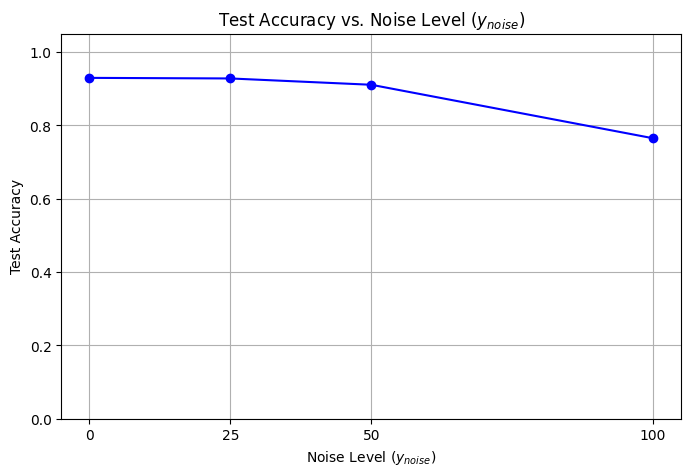

In [5]:
# setup list to store results
accuracies = []

for y_noise in noise_levels:
    # take RAW images
    # add Noise (0-255 scale)
    noisy_raw = addNoiseToMNIST(y_noise, test_images)

    # normalize (0-1 scale) for the network
    noisy_input = noisy_raw / 255.0

    # evaluate
    loss, acc = clean_model.evaluate(noisy_input, test_labels, verbose=0)
    accuracies.append(acc)
    print(f"Noise level {y_noise}: Accuracy = {acc:.4f}")

# plot the results
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, accuracies, marker='o', linestyle='-', color='b')

plt.title('Test Accuracy vs. Noise Level ($y_{noise}$)')
plt.xlabel('Noise Level ($y_{noise}$)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.xticks(noise_levels) # ensure x-axis shows exactly your noise values
plt.ylim(0, 1.05)        # keep y-axis standard (0 to 100%)

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/32
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5408 - loss: 1.5593 - val_accuracy: 0.8885 - val_loss: 0.4937
Epoch 2/32
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8649 - loss: 0.5181 - val_accuracy: 0.9105 - val_loss: 0.3444
Epoch 3/32
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8895 - loss: 0.4015 - val_accuracy: 0.9227 - val_loss: 0.2949
Epoch 4/32
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9034 - loss: 0.3512 - val_accuracy: 0.9255 - val_loss: 0.2717
Epoch 5/32
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9076 - loss: 0.3300 - val_accuracy: 0.9297 - val_loss: 0.2541
Epoch 6/32
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9127 - loss: 0.3093 - val_accuracy: 0.9332 - val_loss: 0.2419
Epoch 7/32
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9197 - loss: 0.2888 - val_accuracy: 0.9373 - val_loss: 0.2313
Epoch 8/32
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9213 - loss: 0.2812 - val_accuracy: 0.

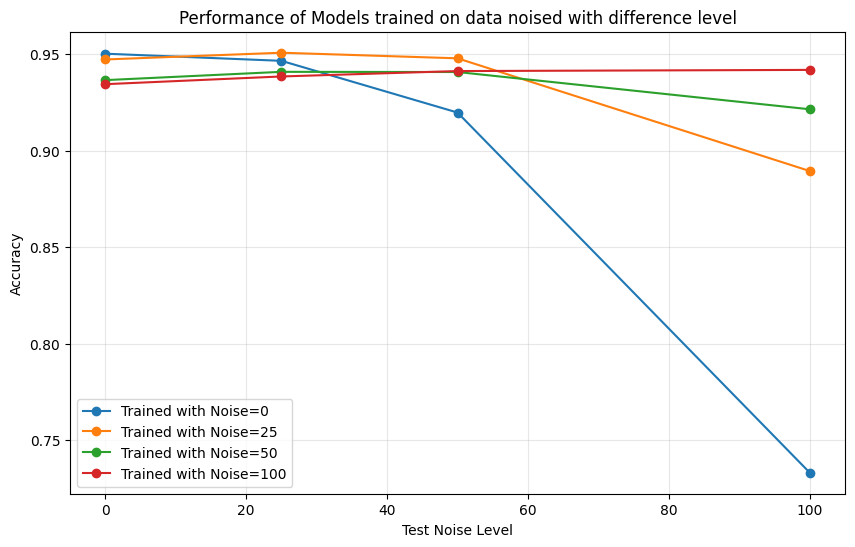

In [7]:
# levels of noise to try adding to the TRAINING data
train_noise_levels = [0, 25, 50, 100]
# dictionary to save results
results = {}

for t_noise in train_noise_levels:
    # prepare noisy training data
    noisy_train_raw = addNoiseToMNIST(t_noise, train_images)
    noisy_train_norm = noisy_train_raw / 255.0

    # train new model
    model = build_and_train_model(noisy_train_norm, train_labels, epochs=32)

    # evaluate this model across all test noise levels
    model_accs = []
    for test_noise in noise_levels:
        noisy_test_raw = addNoiseToMNIST(test_noise, test_images)
        noisy_test_norm = noisy_test_raw / 255.0
        lost, acc = model.evaluate(noisy_test_norm, test_labels, verbose=0)
        model_accs.append(acc)
    # save the results
    results[t_noise] = model_accs

# plot comparison
plt.figure(figsize=(10, 6))
for t_noise, accs in results.items():
    plt.plot(noise_levels, accs, marker='o', label=f'Trained with Noise={t_noise}')
    print(noise_levels, accs)

plt.title('Performance of Models trained on data noised with difference level')
plt.xlabel('Test Noise Level')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Comment
I define performance as the integrated robustness: the ability of the model to maintain high classification accuracy across the entire spectrum of tested noise intensities, rather than just on the clean dataset.

## Performance result:
|Training Noise ($y_{train}$)|Test @ y=0|Test @ y=25|Test @ y=50|Test @ y=100|Mean Performance|
|---|---|---|---|---|---|
|0 (Baseline)|0.950|0.947|0.920|0.733|0.887|
|25|0.947|0.951|0.948|0.890|0.934|
|50|0.937|0.941|0.941|0.922|0.935|
|100|0.934|0.938|0.941|0.942|0.939|

### Training noise = 0
This model achieves the highest accuracy on clean data (95.0%) but suffers a catastrophic failure at high noise levels (73.3% at $y_{noise}=100$).\

The model may has overfit to the clean distribution. It relies on precise pixel patterns that are easily pertubated by noise.

### Training noise = 25 & 50
When training with mild noise ($y_{noise}=25$), the clean accuracy drops negligibly (from 95.0% to 94.7%), but performance on high noise improves dramatically (from 73.3% to 89.0%).

At this point, the noise forces the network to learn more features rather than relying on specific pixel values. It generalizes better without sacrificing significant performance on clean data.

### Training noise = 100
As training noise increases, the model becomes extremely robust (stable performance around ~94% across the board). However, the performance on clean data have a noticeable drop (to 93.7%).

The noise is so strong during training that it obscures fine-grained details. The model learns a "blurry" representation of the digits. While it is consistent, it can no longer reach the peak precision of the clean model.

## What is the best level?
While $y_{train}=100$ technically has the highest average score, its performance drop at clean data which may appears more in real world is still concerning. $y_{train}=50$ shows a stable performance throughout the validation and thus I would suggest it is the best level.